# MURA x-ray classification using Inception model

## Data Preprocessing

In [1]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#import libararies
import os
import glob
import random
from tensorflow import keras
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

In [3]:

# Set the path
onedrive_path = '/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/'
csv_files = glob.glob(onedrive_path + 'final*.csv')

dfs = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    dfs.append(df)

mura_df = pd.concat(dfs, ignore_index=True)

mura_df.to_csv(onedrive_path + 'final_mura_dataset.csv', index=False)

print("\n\tTotal Elbow Images",len(mura_df))
mura_df.head(3)


	Total Elbow Images 1300170


,path,class,label
0,MURA-v1.1/train/XR_FOREARM/patient09083/study1...,XR_FOREARM_POSITIVE,POSITIVE
1,MURA-v1.1/train/XR_FOREARM/patient09083/study1...,XR_FOREARM_POSITIVE,POSITIVE
2,MURA-v1.1/train/XR_FOREARM/patient05601/study1...,XR_FOREARM_POSITIVE,POSITIVE


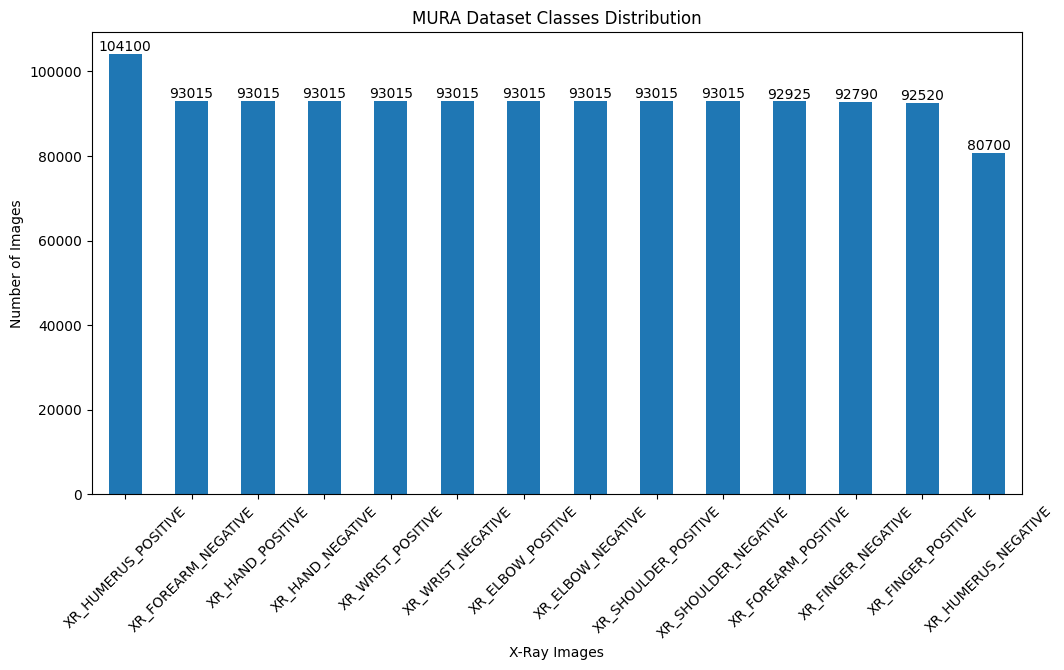

In [4]:
# Count the number of images in each class
mura_df_label_counts = mura_df['class'].value_counts()

# Create a bar chart to visualize the class distribution
plt.figure(figsize=(12, 6))
ax = mura_df_label_counts.plot(kind='bar')
plt.title('MURA Dataset Classes Distribution')
plt.xlabel('X-Ray Images')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add exact counts as text labels on top of each bar
for i, v in enumerate(mura_df_label_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

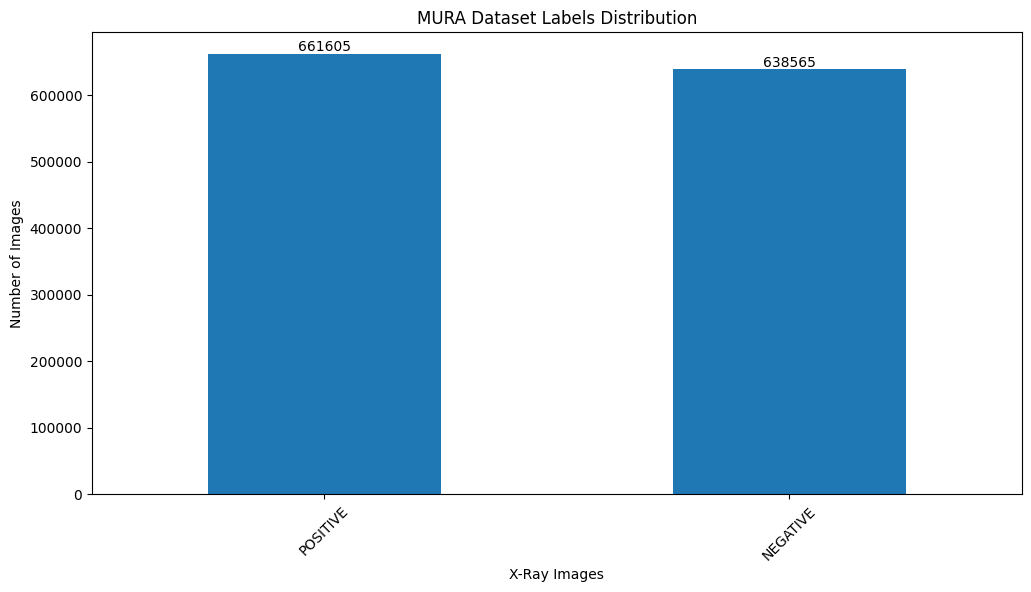

In [5]:
# Count the number of images in each class
mura_df_label_counts = mura_df['label'].value_counts()

# Create a bar chart to visualize the class distribution
plt.figure(figsize=(12, 6))
ax = mura_df_label_counts.plot(kind='bar')
plt.title('MURA Dataset Labels Distribution')
plt.xlabel('X-Ray Images')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add exact counts as text labels on top of each bar
for i, v in enumerate(mura_df_label_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

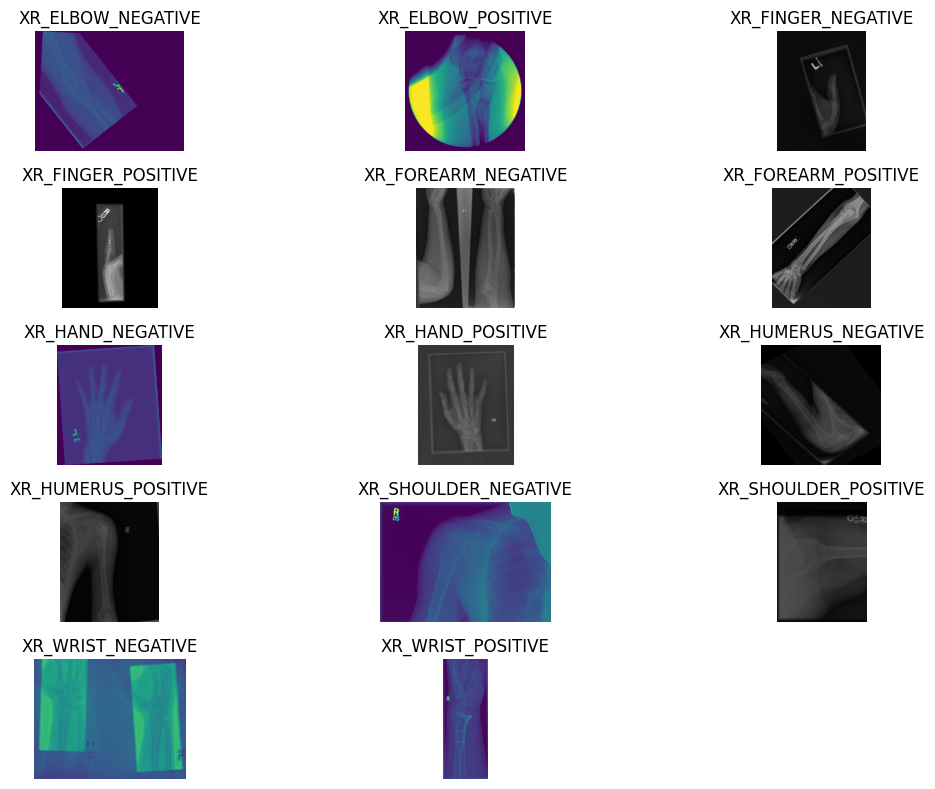

In [6]:
#Display Images of Each class
class_groups = mura_df.groupby('class')['path'].apply(list)

# Create a subplot grid based on the number of classes
num_classes = len(class_groups)
cols = 3
rows = (num_classes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, 8))

for i, (class_name, paths) in enumerate(class_groups.items()):
    random_path = "/content/drive/MyDrive/Extra_work/MURA/" + paths[0]

    image = Image.open(os.path.join(random_path))

    row = i // cols
    col = i % cols

    ax = axes[row, col]
    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis('off')

if num_classes % cols != 0:
    for i in range(num_classes, rows * cols):
        fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.show()

In [ ]:
image_dir = "/content/drive/MyDrive/Extra_work/MURA"

# Split the data into training, validation, and test sets
train_df, test_df = train_test_split(mura_df, test_size=0.15, random_state=42)
val_df, test_df = train_test_split(mura_df, test_size=0.20, random_state=42)

In [ ]:
# Define image data generators for training, validation, and testing

batch_size = 1
image_size = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='path',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)


Found 810439 validated image filenames belonging to 14 classes.


In [ ]:
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='path',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 762766 validated image filenames belonging to 14 classes.


In [ ]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=image_dir,
    x_col='path',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 190692 validated image filenames belonging to 14 classes.


# Train Model

In [ ]:
# Create InceptionV3 base model
base_model = InceptionV3(weights='imagenet', include_top=False)

# Add custom layers for multi-class classification
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)

num_classes = 14
predictions = Dense(num_classes, activation='softmax')(x)

# Combine base model and custom layers
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

87910968/87910968 [==============================] - 0s 0us/step


In [ ]:
# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)

# Define model checkpoint callback to save the best model
model_checkpoint = ModelCheckpoint('/content/drive/MyDrive/Extra_work/MURA/mura_best_model_1.h5',
                                   monitor='val_accuracy',
                                   mode='max',
                                   save_best_only=True)

In [ ]:
# Define the number of training epochs
epochs = 50

# Train the model
history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=epochs,
                    callbacks=[early_stopping, model_checkpoint])


Epoch 1/50
 75425/663086 [==>...........................] - ETA: 24:06:23 - loss: 1.5596 - accuracy: 0.3622

# Create small data set

In [7]:
# Initialize an empty DataFrame for the small version
small_data = pd.DataFrame(columns=['path', 'class', 'label'])

# Define the number of samples you want from each class (550 in this case)
samples_per_class = 550

# Iterate through each class and select the specified number of samples
for class_name in mura_df['class'].unique():
    class_subset = mura_df[mura_df['class'] == class_name].sample(samples_per_class)
    small_data = small_data.append(class_subset, ignore_index=True)

# Shuffle the small dataset to randomize the order
small_data = small_data.sample(frac=1).reset_index(drop=True)

# Save the small dataset to a new CSV file
small_data.to_csv('/content/drive/MyDrive/Extra_work/Sub_dataset/small_data.csv', index=False)

<ipython-input-7-173096b89c93>:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  small_data = small_data.append(class_subset, ignore_index=True)


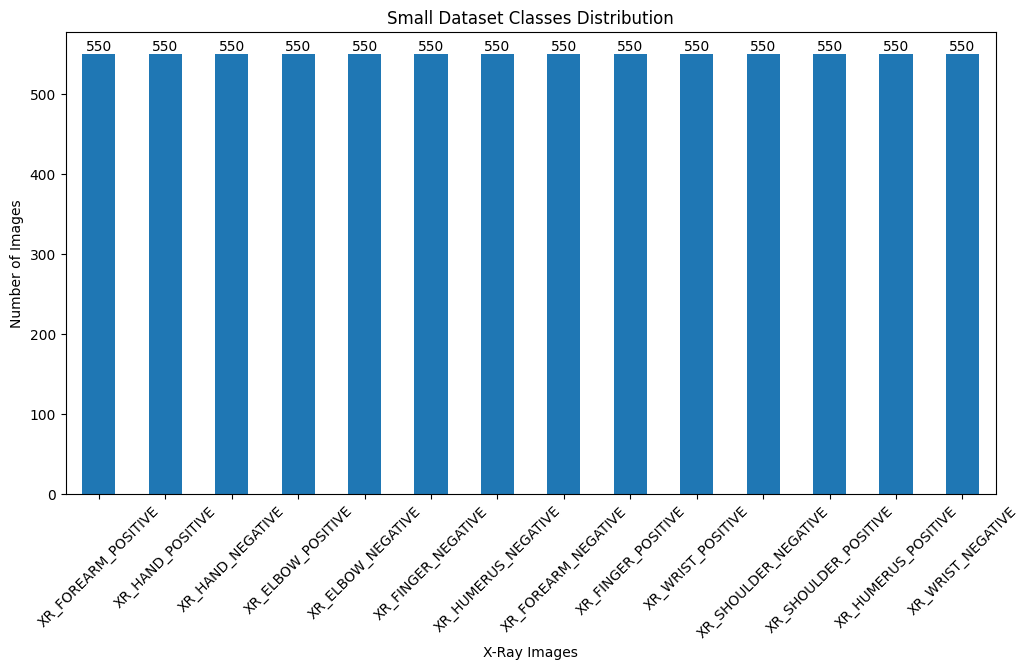

In [9]:
# Count the number of images in each class
small_data_label_counts = small_data['class'].value_counts()

# Create a bar chart to visualize the class distribution
plt.figure(figsize=(12, 6))
ax = small_data_label_counts.plot(kind='bar')
plt.title('Small Dataset Classes Distribution')
plt.xlabel('X-Ray Images')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add exact counts as text labels on top of each bar
for i, v in enumerate(small_data_label_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

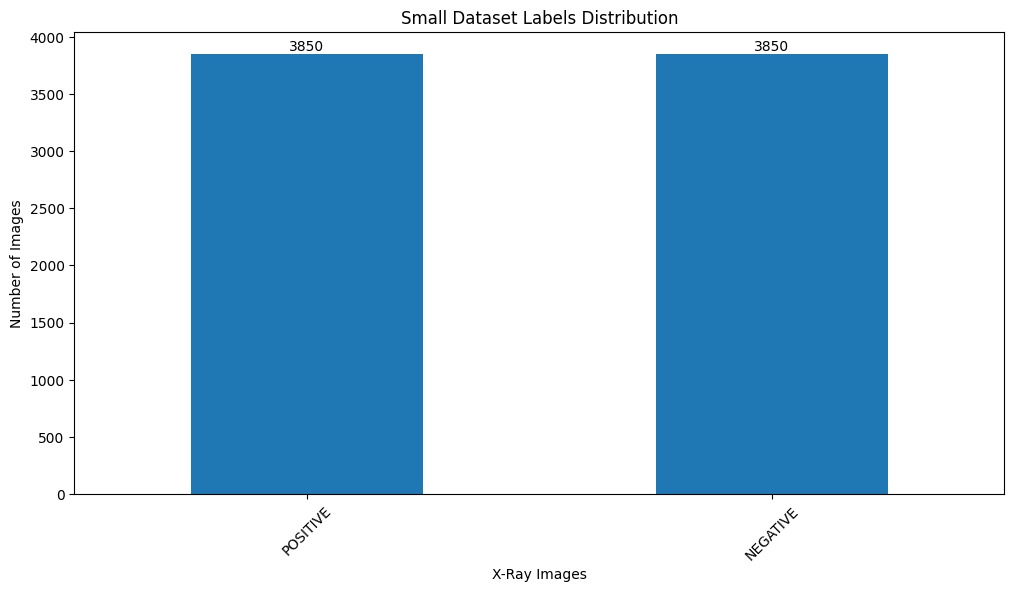

In [10]:
# Count the number of images in each class
small_data_label_counts = small_data['label'].value_counts()

# Create a bar chart to visualize the class distribution
plt.figure(figsize=(12, 6))
ax = small_data_label_counts.plot(kind='bar')
plt.title('Small Dataset Labels Distribution')
plt.xlabel('X-Ray Images')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add exact counts as text labels on top of each bar
for i, v in enumerate(small_data_label_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [13]:
small_data.head(3)

,path,class,label
0,MURA-v1.1/train/XR_FOREARM/augumented_data_xr_...,XR_FOREARM_POSITIVE,POSITIVE
1,MURA-v1.1/train/XR_HAND/patient09897/study1_po...,XR_HAND_POSITIVE,POSITIVE
2,MURA-v1.1/train/XR_HAND/patient05239/study1_ne...,XR_HAND_NEGATIVE,NEGATIVE


In [14]:
image_dir = "/content/drive/MyDrive/Extra_work/MURA"

# Split the data into training, validation, and test sets
train_df, test_df = train_test_split(small_data, test_size=0.15, random_state=42)
val_df, test_df = train_test_split(small_data, test_size=0.20, random_state=42)

In [15]:
# Define image data generators for training, validation, and testing
batch_size = 32
image_size = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [16]:
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='path',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)


Found 6545 validated image filenames belonging to 14 classes.


In [17]:
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='path',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 6160 validated image filenames belonging to 14 classes.


In [18]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=image_dir,
    x_col='path',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1540 validated image filenames belonging to 14 classes.


# Training

In [19]:
# Create InceptionV3 base model
base_small_model = InceptionV3(weights='imagenet', include_top=False)

# Add custom layers for multi-class classification
x = base_small_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)

num_classes = 14
predictions = Dense(num_classes, activation='softmax')(x)

# Combine base model and custom layers
model_small = Model(inputs=base_small_model.input, outputs=predictions)

# Compile the model
model_small.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

87910968/87910968 [==============================] - 0s 0us/step


In [20]:
# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)

# Define model checkpoint callback to save the best model
model_checkpoint = ModelCheckpoint('/content/drive/MyDrive/Extra_work/MURA/mura_small_best_model_1.h5',
                                   monitor='val_accuracy',
                                   mode='max',
                                   save_best_only=True)

In [21]:
# Define the number of training epochs
epochs = 50

# Train the model
history = model_small.fit(train_generator,
                    validation_data=val_generator,
                    epochs=epochs,
                    callbacks=[early_stopping, model_checkpoint])

Epoch 1/50
205/205 [==============================] - ETA: 0s - loss: 1.3333 - accuracy: 0.5062

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


205/205 [==============================] - 1558s 7s/step - loss: 1.3333 - accuracy: 0.5062 - val_loss: 0.8633 - val_accuracy: 0.6609
Epoch 2/50
205/205 [==============================] - 155s 758ms/step - loss: 0.8533 - accuracy: 0.6555 - val_loss: 0.6400 - val_accuracy: 0.7229
Epoch 3/50
205/205 [==============================] - 176s 859ms/step - loss: 0.7132 - accuracy: 0.7132 - val_loss: 0.6059 - val_accuracy: 0.7451
Epoch 4/50
205/205 [==============================] - 164s 799ms/step - loss: 0.6298 - accuracy: 0.7453 - val_loss: 0.4584 - val_accuracy: 0.8093
Epoch 5/50
205/205 [==============================] - 164s 801ms/step - loss: 0.5452 - accuracy: 0.7820 - val_loss: 0.3794 - val_accuracy: 0.8455
Epoch 6/50
205/205 [==============================] - 165s 802ms/step - loss: 0.5225 - accuracy: 0.7881 - val_loss: 0.3727 - val_accuracy: 0.8489
Epoch 7/50
205/205 [==============================] - 158s 771ms/step - loss: 0.4653 - accuracy: 0.8061 - val_loss: 0.3802 - val_accuracy

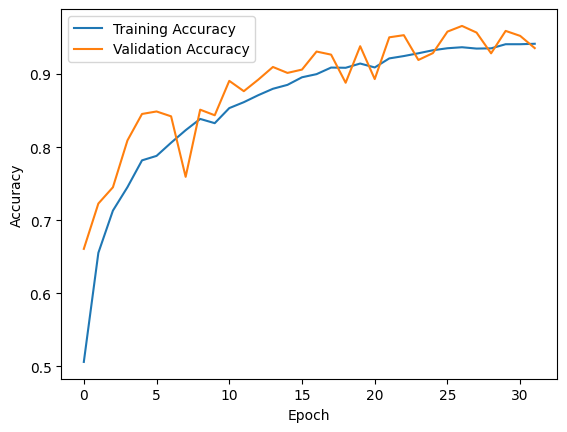

In [22]:
# Visualize training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

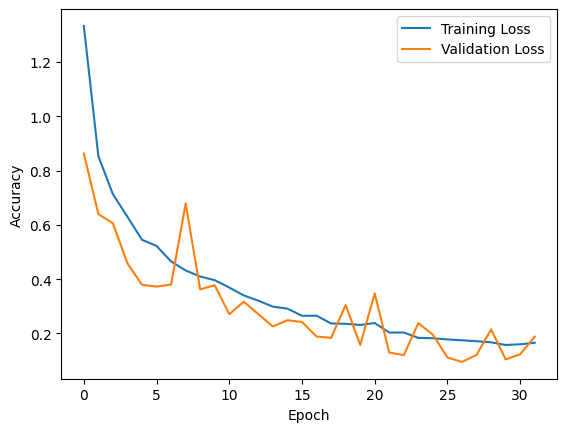

In [23]:
# Visualize training accuracy
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Testing

In [37]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# Reset the test generator to the beginning
test_generator.reset()

model_small = load_model("/content/drive/MyDrive/Extra_work/MURA/mura_small_best_model_1.h5")

# Make predictions on the test data
predictions = model_small.predict(test_generator)

# Get the true labels for the test data
true_labels = test_generator.classes

# Get the class labels of the generator
class_labels = list(test_generator.class_indices.keys())

# Create a mapping of class indices to class labels
class_indices = test_generator.class_indices
class_labels = {v: k for k, v in class_indices.items()}

# Select 12 random samples from the test data
num_samples = 12
sample_indices = np.random.choice(len(predictions), num_samples, replace=False)

49/49 [==============================] - 10s 182ms/step


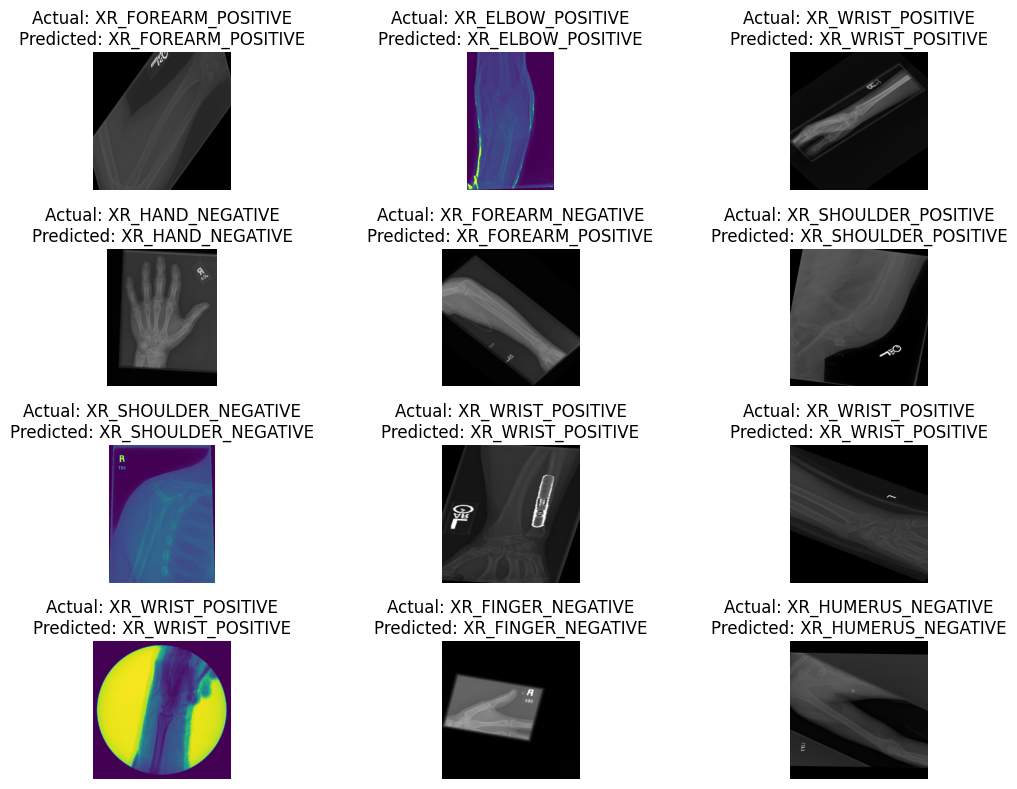

In [31]:
# Display the images along with the actual and predicted labels for the selected samples
plt.figure(figsize=(12, 8))
for i, index in enumerate(sample_indices):
    actual_label = class_labels[true_labels[index]]
    predicted_label = class_labels[np.argmax(predictions[index])]

    # Load and display the image
    img_path = os.path.join(image_dir, test_generator.filenames[index])
    img = plt.imread(img_path)
    plt.subplot(4, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

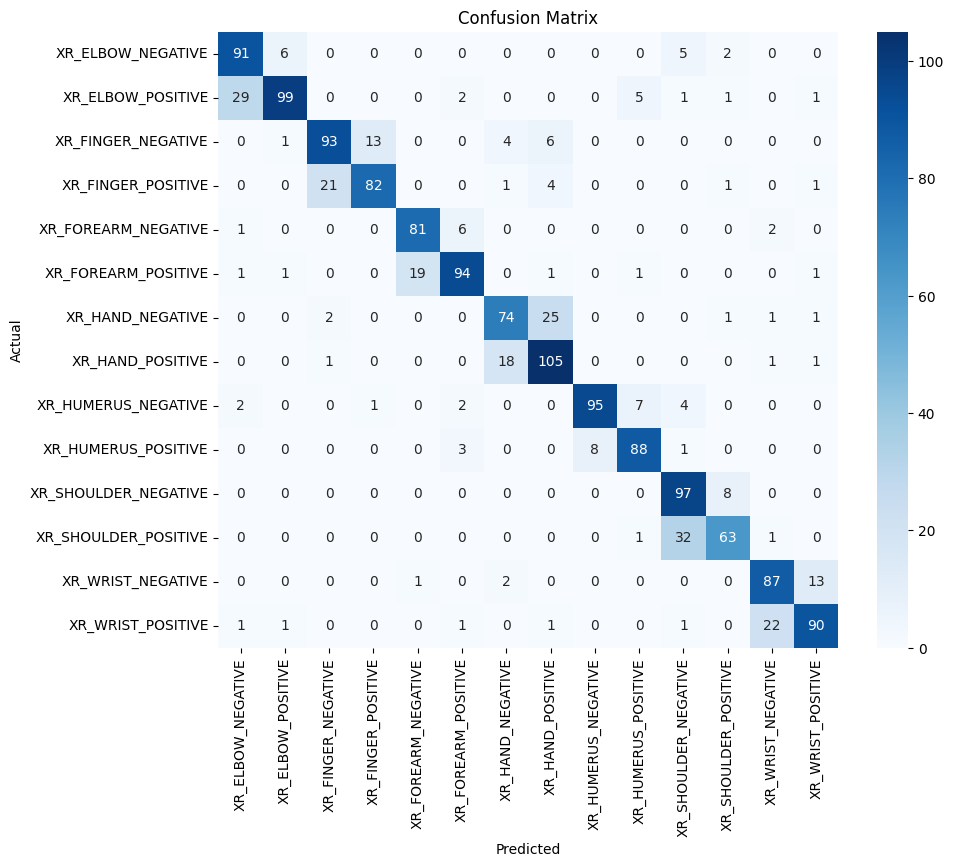

In [33]:
# Compute the confusion matrix
confusion_mat = confusion_matrix(true_labels, np.argmax(predictions, axis=1))

# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels.values(), yticklabels=class_labels.values())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [35]:
f1 = f1_score(true_labels, np.argmax(predictions, axis=1), average='weighted')
print(f'Weighted F1 Score: {f1:.4f}')

Weighted F1 Score: 0.8043


In [38]:
# Generate a classification report
class_report = classification_report(true_labels, np.argmax(predictions, axis=1), target_names=class_labels.values())

# Print the classification report
print(class_report)

                      precision    recall  f1-score   support

   XR_ELBOW_NEGATIVE       0.73      0.88      0.79       104
   XR_ELBOW_POSITIVE       0.92      0.72      0.80       138
  XR_FINGER_NEGATIVE       0.79      0.79      0.79       117
  XR_FINGER_POSITIVE       0.85      0.75      0.80       110
 XR_FOREARM_NEGATIVE       0.80      0.90      0.85        90
 XR_FOREARM_POSITIVE       0.87      0.80      0.83       118
    XR_HAND_NEGATIVE       0.75      0.71      0.73       104
    XR_HAND_POSITIVE       0.74      0.83      0.78       126
 XR_HUMERUS_NEGATIVE       0.92      0.86      0.89       111
 XR_HUMERUS_POSITIVE       0.86      0.88      0.87       100
XR_SHOULDER_NEGATIVE       0.69      0.92      0.79       105
XR_SHOULDER_POSITIVE       0.83      0.65      0.73        97
   XR_WRIST_NEGATIVE       0.76      0.84      0.80       103
   XR_WRIST_POSITIVE       0.83      0.77      0.80       117

            accuracy                           0.80      1540
      

# Tranfer learn

In [39]:
# Initialize an empty DataFrame for the small version
TL_data = pd.DataFrame(columns=['path', 'class', 'label'])

# Define the number of samples you want from each class (550 in this case)
samples_per_class = 1550

# Iterate through each class and select the specified number of samples
for class_name in mura_df['class'].unique():
    class_subset = mura_df[mura_df['class'] == class_name].sample(samples_per_class)
    TL_data = TL_data.append(class_subset, ignore_index=True)

# Shuffle the small dataset to randomize the order
TL_data = TL_data.sample(frac=1).reset_index(drop=True)

# Save the small dataset to a new CSV file
TL_data.to_csv('/content/drive/MyDrive/Extra_work/Sub_dataset/TL_mura_data.csv', index=False)

<ipython-input-39-e69f8a38f2ae>:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  TL_data = TL_data.append(class_subset, ignore_index=True)


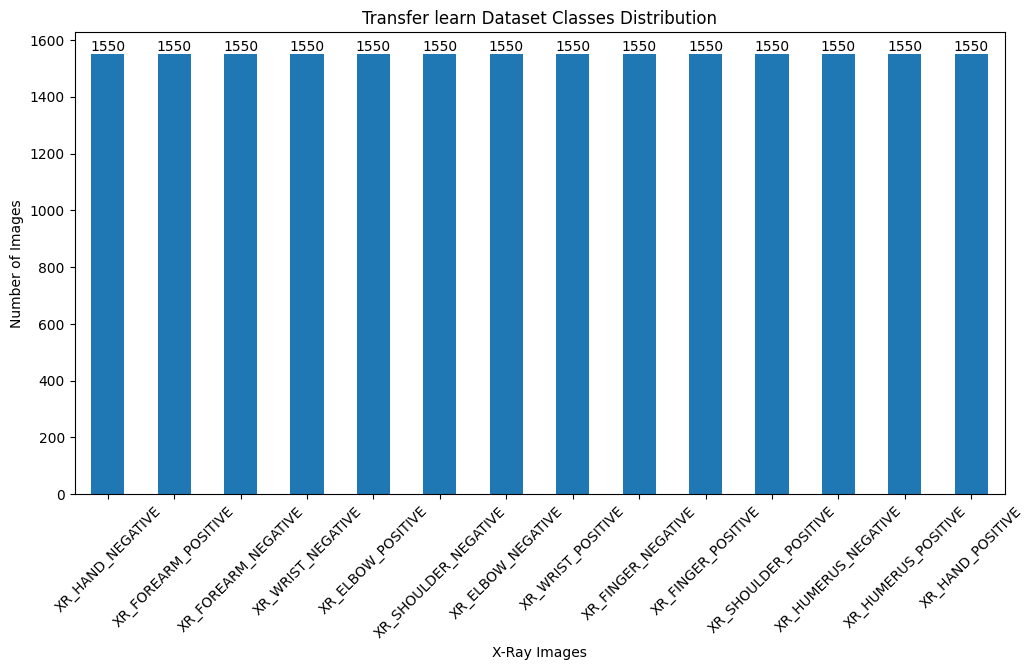

In [41]:
# Count the number of images in each class
TL_data_label_counts = TL_data['class'].value_counts()

# Create a bar chart to visualize the class distribution
plt.figure(figsize=(12, 6))
ax = TL_data_label_counts.plot(kind='bar')
plt.title('Transfer learn Dataset Classes Distribution')
plt.xlabel('X-Ray Images')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add exact counts as text labels on top of each bar
for i, v in enumerate(TL_data_label_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

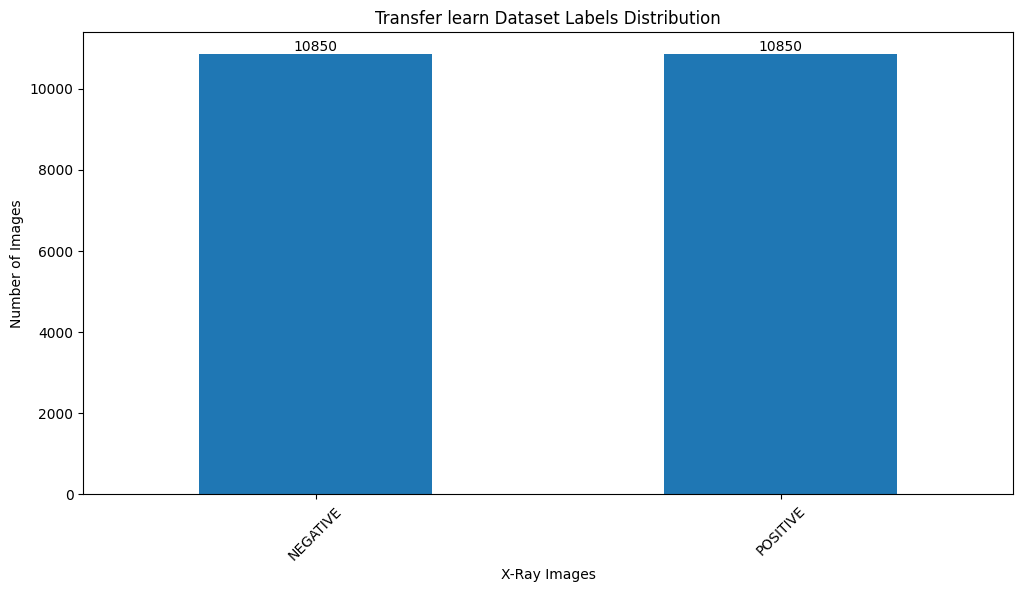

In [42]:
# Count the number of images in each class
TL_data_label_counts = TL_data['label'].value_counts()

# Create a bar chart to visualize the class distribution
plt.figure(figsize=(12, 6))
ax = TL_data_label_counts.plot(kind='bar')
plt.title('Transfer learn Dataset Labels Distribution')
plt.xlabel('X-Ray Images')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add exact counts as text labels on top of each bar
for i, v in enumerate(TL_data_label_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [43]:
TL_data.head(3)

,path,class,label
0,MURA-v1.1/train/XR_HAND/patient00604/study1_ne...,XR_HAND_NEGATIVE,NEGATIVE
1,MURA-v1.1/train/XR_FOREARM/augumented_data_xr_...,XR_FOREARM_POSITIVE,POSITIVE
2,MURA-v1.1/train/XR_FOREARM/patient09264/study1...,XR_FOREARM_POSITIVE,POSITIVE


In [44]:
image_dir = "/content/drive/MyDrive/Extra_work/MURA"

# Split the data into training, validation, and test sets
TL_train_df, TL_test_df = train_test_split(TL_data, test_size=0.15, random_state=42)
TL_val_df, TL_test_df = train_test_split(TL_data, test_size=0.20, random_state=42)

In [45]:
# Define image data generators for training, validation, and testing
batch_size = 64
image_size = (224, 224)

TL_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [46]:
TL_val_datagen = ImageDataGenerator(rescale=1./255)
TL_test_datagen = ImageDataGenerator(rescale=1./255)

TL_train_generator = train_datagen.flow_from_dataframe(
    dataframe=TL_train_df,
    directory=image_dir,
    x_col='path',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)


Found 18445 validated image filenames belonging to 14 classes.


In [47]:
TL_val_generator = val_datagen.flow_from_dataframe(
    dataframe=TL_val_df,
    directory=image_dir,
    x_col='path',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 17360 validated image filenames belonging to 14 classes.


In [48]:
TL_test_generator = test_datagen.flow_from_dataframe(
    dataframe=TL_test_df,
    directory=image_dir,
    x_col='path',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 4340 validated image filenames belonging to 14 classes.


In [49]:
# Load the previously saved model
saved_model_path = '/content/drive/MyDrive/Extra_work/MURA/mura_small_best_model_1.h5'
TL_model = load_model(saved_model_path)

In [50]:
# Compile the model (you can adjust the learning rate if needed)
TL_model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Define model checkpoint callback to save the best model
model_checkpoint = ModelCheckpoint('/content/drive/MyDrive/Extra_work/MURA/TL_mura_small_best_model_1.h5',
                                   monitor='val_loss',
                                   save_best_only=True)

In [51]:
# Define the number of additional training epochs
additional_epochs = 50

# Train the model further
history = TL_model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=additional_epochs,
                    callbacks=[early_stopping, model_checkpoint])

Epoch 1/50
205/205 [==============================] - ETA: 0s - loss: 0.0628 - accuracy: 0.9332

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


205/205 [==============================] - 197s 789ms/step - loss: 0.0628 - accuracy: 0.9332 - val_loss: 0.0155 - val_accuracy: 0.9666
Epoch 2/50
205/205 [==============================] - 157s 768ms/step - loss: 0.0264 - accuracy: 0.9421 - val_loss: 0.0244 - val_accuracy: 0.9481
Epoch 3/50
205/205 [==============================] - 159s 778ms/step - loss: 0.0257 - accuracy: 0.9422 - val_loss: 0.0297 - val_accuracy: 0.9255
Epoch 4/50
205/205 [==============================] - 177s 865ms/step - loss: 0.0243 - accuracy: 0.9430 - val_loss: 0.0150 - val_accuracy: 0.9651
Epoch 5/50
205/205 [==============================] - 154s 749ms/step - loss: 0.0199 - accuracy: 0.9554 - val_loss: 0.0209 - val_accuracy: 0.9555
Epoch 6/50
205/205 [==============================] - 155s 754ms/step - loss: 0.0228 - accuracy: 0.9462 - val_loss: 0.0186 - val_accuracy: 0.9583
Epoch 7/50
205/205 [==============================] - 163s 794ms/step - loss: 0.0214 - accuracy: 0.9497 - val_loss: 0.0291 - val_accura

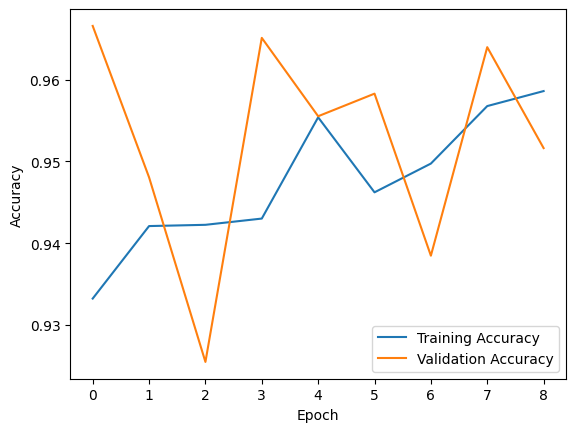

In [52]:
# Visualize training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

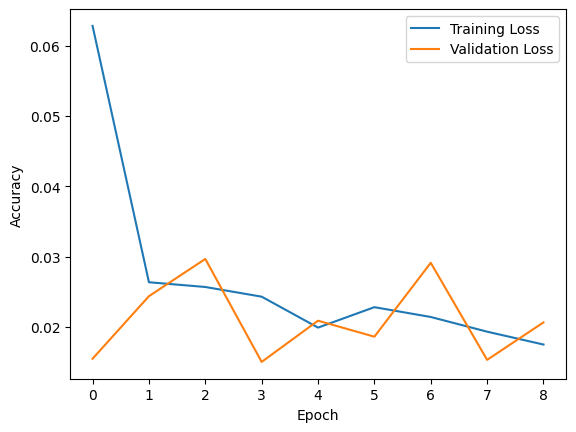

In [53]:
# Visualize training accuracy
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Testing

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# Reset the test generator to the beginning
test_generator.reset()

model_small = load_model("/content/drive/MyDrive/Extra_work/MURA/TL_best_model.h5")

# Make predictions on the test data
predictions = model_small.predict(test_generator)

# Get the true labels for the test data
true_labels = test_generator.classes

# Get the class labels of the generator
class_labels = list(test_generator.class_indices.keys())

# Create a mapping of class indices to class labels
class_indices = test_generator.class_indices
class_labels = {v: k for k, v in class_indices.items()}

# Select 12 random samples from the test data
num_samples = 12
sample_indices = np.random.choice(len(predictions), num_samples, replace=False)

78/78 [==============================] - 906s 12s/step
Sample Predictions:
[[0]
 [0]
 [0]
 [1]
 [1]]


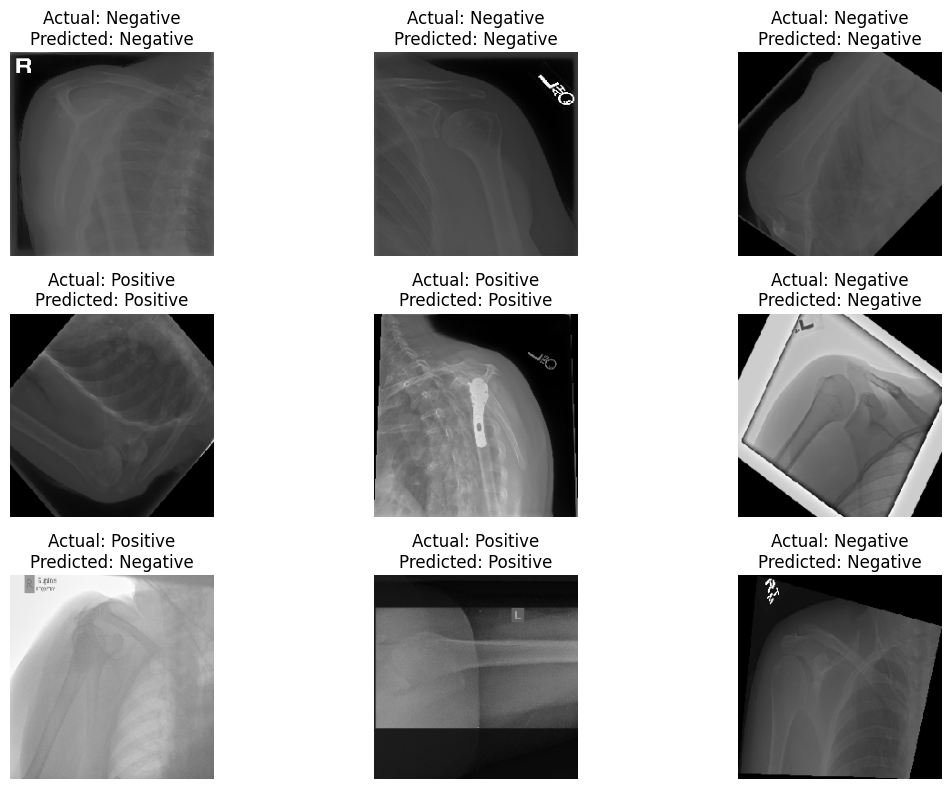

In [ ]:
# Get some test images for display
test_images, test_labels = next(test_generator)

# Create a 3x3 grid of subplots to display images and their labels
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[i])
    true_label = "Actual: Negative" if test_labels[i] == 0 else "Actual: Positive"
    pred_label = "Predicted: Negative" if binary_predictions[i] == 0 else "Predicted: Positive"
    plt.title(f"{true_label}\n{pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

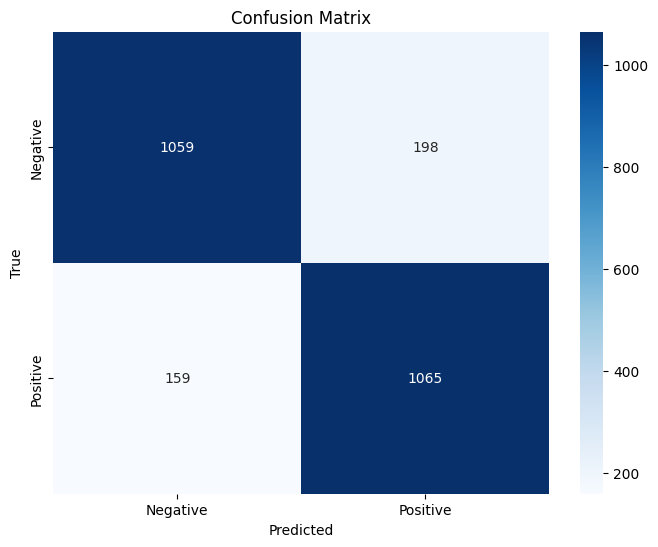

In [ ]:
# Get the true labels from the test generator
true_labels = test_generator.classes

# Calculate the confusion matrix
confusion = confusion_matrix(true_labels, binary_predictions)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Calculate the F1 score
f1 = f1_score(true_labels, binary_predictions)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8565


In [ ]:
history.history

{'loss': [0.12081655859947205,
  0.10357082635164261,
  0.11287469416856766,
  0.10610241442918777,
  0.10726017504930496,
  0.09947048127651215],
 'accuracy': [0.9548429846763611,
  0.9601556062698364,
  0.9550327062606812,
  0.960060715675354,
  0.9593966603279114,
  0.9617683291435242],
 'val_loss': [0.055003952234983444,
  0.11463043093681335,
  0.14114198088645935,
  0.06866177171468735,
  0.0748765841126442,
  0.11936438828706741],
 'val_accuracy': [0.9807479381561279,
  0.9642173051834106,
  0.9518193602561951,
  0.9742969274520874,
  0.970466673374176,
  0.956052839756012]}